# AIC lattice of cognitive models

Draws the model space as a lattice: one row per number of mechanisms (single, two-way, three-way), one box per mechanism combination, and the AIC of the M1 variant. Edges link each combination to the simpler models it is built from.

In [29]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyBboxPatch

sys.path.append("../src")

from Config.config import PATHS

## Model space

`LATTICE` maps each level (number of mechanisms) to the nodes on that row, as `(box title, model-name stem)`. A stem that is itself a model name (`ICSM`) is used as-is; otherwise the `-M1` variant is looked up. `EDGES` lists the `(parent, child)` links between titles.

In [30]:
# RESULTS_FILE = 'best_fit_small.json'
# RESULTS_FILE = 'best_fit_generic.json'
RESULTS_FILE = 'best_fit_all_generic.json'
VARIANT = 'M1'

LATTICE = {
    1: [
        ('Fairness', 'OnlyFairness'),
        ('Payoff', 'Payoff'),
        ('Attendance', 'OnlyAttendance'),
        ('ICSM', 'ICSM'),
    ],
    2: [
        ('Fairness + Payoff', 'Fairness'),
        ('Attendance + Payoff', 'Attendance'),
        ('Payoff + ICSM', 'Payoff+ICSM'),
    ],
    3: [
        ('Fairness + Payoff + ICSM', 'Fairness+Payoff+ICSM'),
        ('Attendance + Payoff + ICSM', 'Attendance+Payoff+ICSM'),
    ],
}

EDGES = [
    ('Fairness', 'Fairness + Payoff'),
    ('Payoff', 'Fairness + Payoff'),
    ('Payoff', 'Attendance + Payoff'),
    ('Attendance', 'Attendance + Payoff'),
    ('Payoff', 'Payoff + ICSM'),
    ('ICSM', 'Payoff + ICSM'),
    ('Fairness + Payoff', 'Fairness + Payoff + ICSM'),
    ('Payoff + ICSM', 'Fairness + Payoff + ICSM'),
    ('Payoff + ICSM', 'Attendance + Payoff + ICSM'),
    ('Attendance + Payoff', 'Attendance + Payoff + ICSM'),
]

In [31]:
aic = (
    pd.read_json(PATHS['parameter_fit_results'] / RESULTS_FILE, lines=True)
    .set_index('model_name')['AIC']
)


def entries(stem: str) -> list:
    """Return [(empty label, AIC or None, model name)] for the M1 node."""
    name = stem if stem in aic.index else f'{stem}-{VARIANT}'
    value = float(aic[name]) if name in aic.index else None
    return [('', value, name)]


nodes = {
    title: {'level': level, 'entries': entries(stem)}
    for level, members in LATTICE.items()
    for title, stem in members
}

best = min(
    (e for n in nodes.values() for e in n['entries'] if e[1] is not None),
    key=lambda e: e[1],
)[2]

missing = [e[2] for n in nodes.values() for e in n['entries'] if e[1] is None]
print(f'Best fit: {best} (AIC = {aic[best]:,.1f})')
print(f'Not in {RESULTS_FILE}: {missing}')

Best fit: Attendance+Payoff+ICSM-M1 (AIC = 38,867.0)
Not in best_fit_all_generic.json: []


## Figure

Saved /Users/edgarjoseandradelotero/GitHub/Cognitive_Models_El_Farol_Bar_Problem/images/exploratory/aic_model_lattice.png


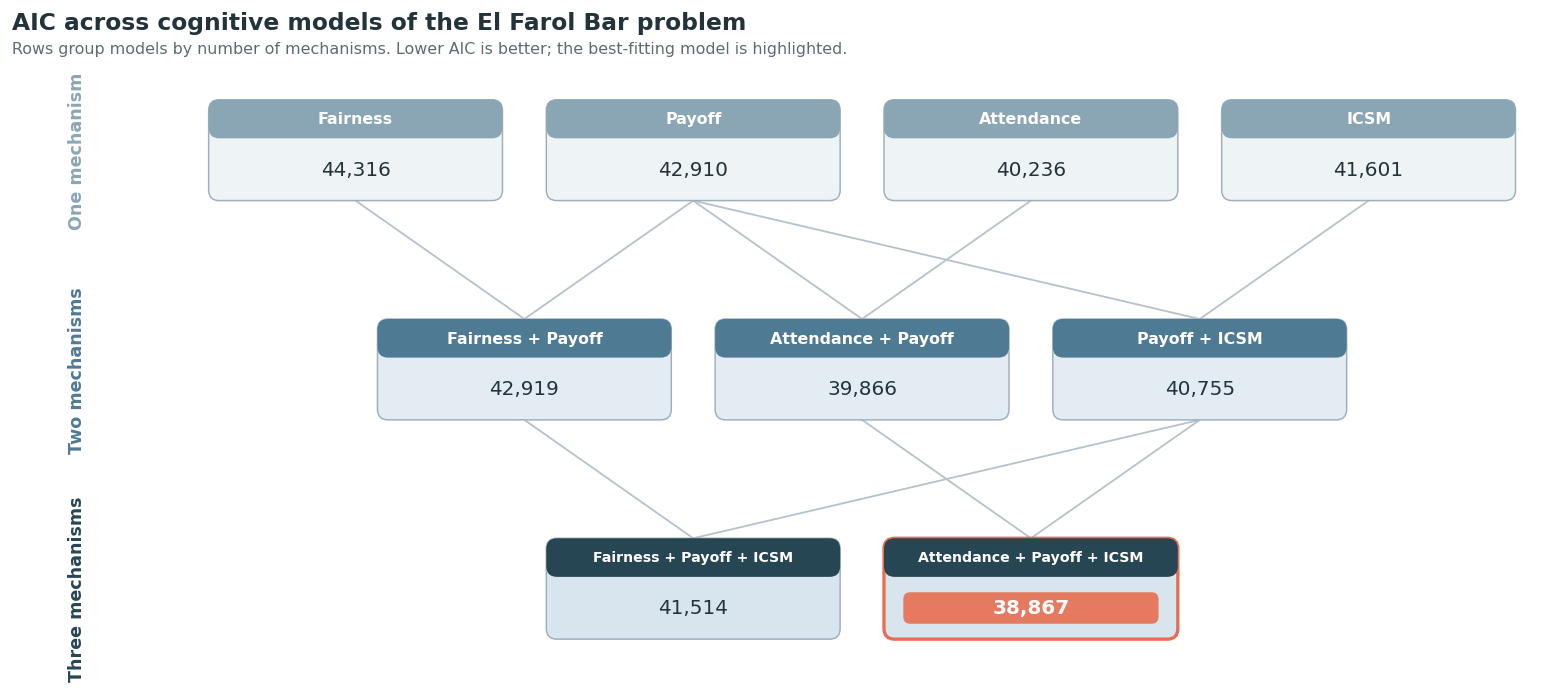

In [32]:
BOX_W, BOX_H, X_GAP, Y_GAP = 3.35, 1.15, 0.5, 1.35
LEVEL_FILL = {1: '#eef3f6', 2: '#e3ecf2', 3: '#d8e5ee'}
LEVEL_HEAD = {1: '#8aa5b4', 2: '#4e7a94', 3: '#264653'}
CAPTIONS = {1: 'One mechanism', 2: 'Two mechanisms', 3: 'Three mechanisms'}
ACCENT = '#e76f51'

row_width = {lv: len(m) * BOX_W + (len(m) - 1) * X_GAP for lv, m in LATTICE.items()}
canvas_w = max(row_width.values())
n_levels = len(LATTICE)

for level, members in LATTICE.items():
    x0 = (canvas_w - row_width[level]) / 2
    y = (n_levels - level) * (BOX_H + Y_GAP)
    for i, (title, _) in enumerate(members):
        nodes[title]['xy'] = (x0 + i * (BOX_W + X_GAP) + BOX_W / 2, y + BOX_H / 2)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
})

fig, ax = plt.subplots(figsize=(13, 7.6))
ax.set_xlim(-1.9, canvas_w + 0.3)
ax.set_ylim(-0.5, n_levels * (BOX_H + Y_GAP) - Y_GAP + 0.5)
ax.set_aspect('equal')
ax.axis('off')

for parent, child in EDGES:
    px, py = nodes[parent]['xy']
    cx, cy = nodes[child]['xy']
    ax.annotate(
        '',
        xy=(cx, cy + BOX_H / 2),
        xytext=(px, py - BOX_H / 2),
        arrowprops=dict(arrowstyle='-', color='#b6c2cc', linewidth=1.1,
                        shrinkA=0, shrinkB=0),
        zorder=1,
    )

for title, node in nodes.items():
    cx, cy = node['xy']
    level = node['level']
    left, bottom = cx - BOX_W / 2, cy - BOX_H / 2
    holds_best = any(e[2] == best for e in node['entries'])

    ax.add_patch(FancyBboxPatch(
        (left, bottom), BOX_W, BOX_H,
        boxstyle='round,pad=0,rounding_size=0.12',
        facecolor=LEVEL_FILL[level],
        edgecolor=ACCENT if holds_best else '#9fb0bd',
        linewidth=2.0 if holds_best else 0.9,
        zorder=2,
    ))

    head_h = 0.44
    ax.add_patch(FancyBboxPatch(
        (left, bottom + BOX_H - head_h), BOX_W, head_h,
        boxstyle='round,pad=0,rounding_size=0.12',
        facecolor=LEVEL_HEAD[level], edgecolor='none', zorder=3,
    ))
    ax.text(
        cx, bottom + BOX_H - head_h / 2, title,
        ha='center', va='center', color='white',
        fontsize=9.5 if len(title) <= 20 else 8.5, fontweight='bold', zorder=4,
    )

    y = bottom + (BOX_H - head_h) / 2
    _, value, name = node['entries'][0]
    is_best = name == best
    if is_best:
        ax.add_patch(FancyBboxPatch(
            (left + 0.22, y - 0.18), BOX_W - 0.44, 0.36,
            boxstyle='round,pad=0,rounding_size=0.08',
            facecolor=ACCENT, edgecolor='none', alpha=0.9, zorder=4,
        ))
    color = 'white' if is_best else ('#8c99a4' if value is None else '#22333b')
    ax.text(
        cx, y, '\u2014' if value is None else f'{value:,.0f}',
        ha='center', va='center', fontsize=12, color=color,
        fontweight='bold' if is_best else 'medium', zorder=5,
    )

for level in LATTICE:
    y = (n_levels - level) * (BOX_H + Y_GAP) + BOX_H / 2
    ax.text(-1.5, y, CAPTIONS[level], ha='center', va='center', rotation=90,
            fontsize=10.5, color=LEVEL_HEAD[level], fontweight='bold')

ax.set_title(
    'AIC across cognitive models of the El Farol Bar problem',
    fontsize=14, fontweight='bold', color='#22333b', pad=16, loc='left', x=-0.02,
)
ax.text(
    -0.02, 1.0,
    'Rows group models by number of mechanisms. '
    'Lower AIC is better; the best-fitting model is highlighted.',
    transform=ax.transAxes, ha='left', va='bottom', fontsize=9.5, color='#5c6b73',
)

fig.tight_layout()
out = PATHS['exploratory_figures'] / 'aic_model_lattice.png'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches='tight', facecolor='white')
print('Saved', out)
plt.show()